# Potencial Talents

## Importing Dependencies

In [1]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.compose import make_column_transformer

from sentence_transformers import SentenceTransformer
from wordcloud import WordCloud

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

print('Modules Imported')

Modules Imported


## Import Data

In [2]:
data_path = 'potential-talents.xlsx'

In [3]:
data = pd.read_excel(data_path)

print(f'This Dataset contains {len(data)} records.\n')

# Printing first values
data.head()

This Dataset contains 104 records.



,id,job_title,location,connection,fit
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN


This dataset contains 104 records. However, some entries are duplicates when the `id` column is ignored.

Since the `id` column does not contribute meaningful information for similarity or ranking, duplicate records may negatively impact the analysis. Therefore, it is important to identify and remove these redundancies before proceeding.

## Exploring Dataset

### Columns

**X:**

- `id`: unique identifier for candidate (numeric)
- `job_title`: job title for candidate (text)
- `location`: geographical location for candidate (text)
- `connections`: number of connections candidate has, 500+ means over 500 (text)

**Y:**

- `fit`: how fit the candidate is for the role? (numeric, probability between 0-1)

### Cleaning Dataset

In [4]:
data = data.drop(columns=['id']).drop_duplicates().reset_index(drop=True)

data

,job_title,location,connection,fit
0,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN
1,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN
2,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN
3,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN
4,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN
5,Aspiring Human Resources Specialist,Greater New York City Area,1,NaN
6,Student at Humber College and Aspiring Human R...,Kanada,61,NaN
7,HR Senior Specialist,San Francisco Bay Area,500+,NaN
8,Seeking Human Resources HRIS and Generalist Po...,Greater Philadelphia Area,500+,NaN
9,Student at Chapman University,"Lake Forest, California",2,NaN


After removing the `id` column and dropping duplicate rows, the dataset is now cleaner and more consistent.

This step improves:
- The quality of similarity calculations
- The performance of embedding generation
- The efficiency of manual analysis

#### Cleaning Job Titles

In [5]:
job_titles = data['job_title']

job_titles.head()

0    2019 C.T. Bauer College of Business Graduate (...
1    Native English Teacher at EPIK (English Progra...
2                Aspiring Human Resources Professional
3               People Development Coordinator at Ryan
4      Advisory Board Member at Celal Bayar University
Name: job_title, dtype: object

Fetching job titles from the dataframe

In [6]:
def remove_noise(text):
    if pd.isna(text):
        return text
    text = re.sub(r'\d+', '', text)  
    text = re.sub(r'[|/\\\-_,]', ' ', text)  
    text = re.sub(r'\(.*?\)', '', text)  
    text = re.sub('create','', text)
    text = re.sub('within','', text)
    text = re.sub('Ryan','', text)
    text = re.sub('Victoria','', text)
    text = re.sub('Bauer','', text)
    text = re.sub('Indiana','', text)
    text = re.sub('Delphi','', text)
    text = re.sub('Luxottica','', text)
    text = re.sub('Kokomo','', text)
    text = re.sub('Illinois','', text)
    text = re.sub('Bayar','', text)
    text = re.sub('Atlanta','', text)
    text = re.sub('Louis','', text)
    text = re.sub('Chapman','', text)
    text = re.sub('Loparex','', text)
    text = re.sub('ScottMadden','', text)
    text = re.sub('Styczynski','', text)
    text = re.sub('Wellington','', text)
    return text

job_titles = job_titles.apply(remove_noise)

**Cleaning meaningless or noisy information helps improve both the quality and efficiency of the embeddings**.

By removing elements such as numbers, special characters, and irrelevant patterns, the text becomes more consistent and focused on meaningful terms. This leads to better semantic representations and can slightly reduce processing time during vectorization.

### Most Repetead Words

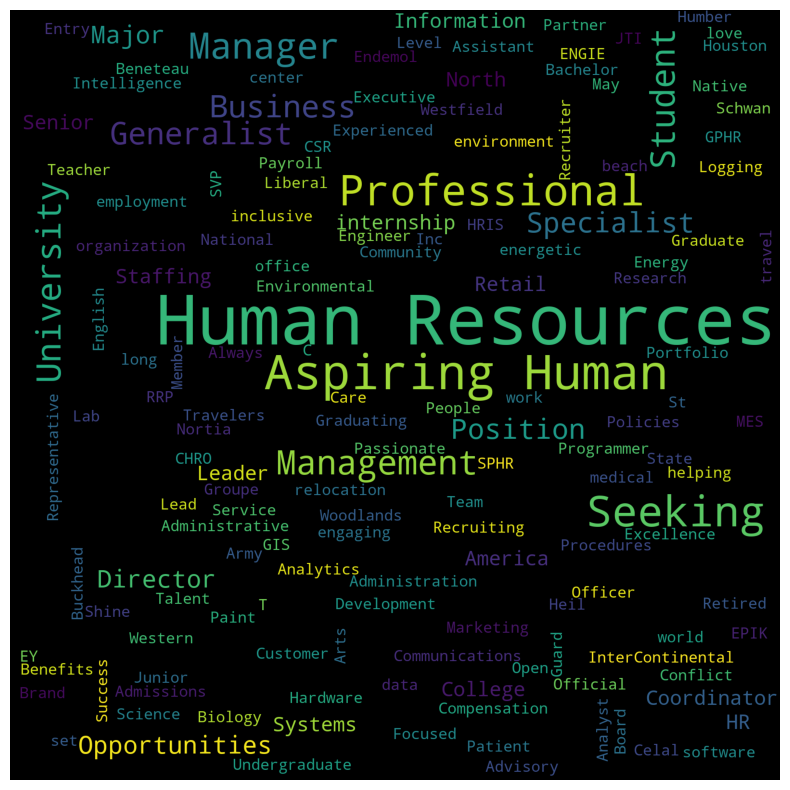

In [7]:
text = " ".join(job_titles)

wordcloud = WordCloud(width=1600, height=1600).generate(text)

plt.subplots(1, 1, figsize=(12,10))

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

This visualization highlights the most frequent terms found in the `job_title` field, providing a quick overview of common patterns in candidate roles.

## Vector Search

### Defining keywords

In [8]:
keywords = ['Aspiring human resources','seeking human resources'] 

These are the keywords that will be used to rank potential candidates

### Get Embedding

In [9]:
# Load a pre-trained Sentence Transformer model for generating text embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Convert job titles into dense vector representations (embeddings)
job_title_embedding = embedding_model.encode(job_titles, normalize_embeddings=True)

# Convert keywords into dense vector representations (embeddings)
keywords_embedding = embedding_model.encode(keywords, normalize_embeddings=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     | Details
------------------------+------------+--------
embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Getting Vector Similarity

In [10]:
resulting_matrix = cosine_similarity(job_title_embedding, keywords_embedding)

resulting_matrix = resulting_matrix.max(axis=1)

Text data must be converted into embeddings to enable similarity comparisons. These embeddings are **generated by the Sentence Transformer Model** and **use cosine similarity to measure how close texts are**.

Here, the maximum similarity score is selected for each candidate, representing the strongest match between their job title and the provided keywords.

### Adding Similarity Score to Dataframe

In [11]:
# Adding the score data to the fit column
data = data.assign(fit=resulting_matrix)

data.head()

,job_title,location,connection,fit
0,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,0.664928
1,Native English Teacher at EPIK (English Progra...,Kanada,500+,0.215083
2,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.949808
3,People Development Coordinator at Ryan,"Denton, Texas",500+,0.504929
4,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,0.230514


In [12]:
# Sorting candidates based on the "fit" feature (measures the similarity between the job title and the chosen keywords)
sorted_fit_data = data.sort_values(by=['fit'], ascending=False)

# Printing the top 10 candidates
sorted_fit_data.head(10)

,job_title,location,connection,fit
2,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.949808
45,Aspiring Human Resources Professional,"Kokomo, Indiana Area",71,0.949808
5,Aspiring Human Resources Specialist,Greater New York City Area,1,0.928035
47,Seeking Human Resources Position,"Las Vegas, Nevada Area",48,0.904125
13,Seeking Human Resources Opportunities,"Chicago, Illinois",390,0.899172
8,Seeking Human Resources HRIS and Generalist Po...,Greater Philadelphia Area,500+,0.807988
22,Human Resources Professional,Greater Boston Area,16,0.794648
30,Aspiring Human Resources Professional | An ene...,"Austin, Texas Area",174,0.776667
16,Human Resources Specialist at Luxottica,Greater New York City Area,500+,0.771757
6,Student at Humber College and Aspiring Human R...,Kanada,61,0.757811


### Keyword Similarity Data

Text(0.5, 1.0, 'Candidates by Job Title Compatibility')

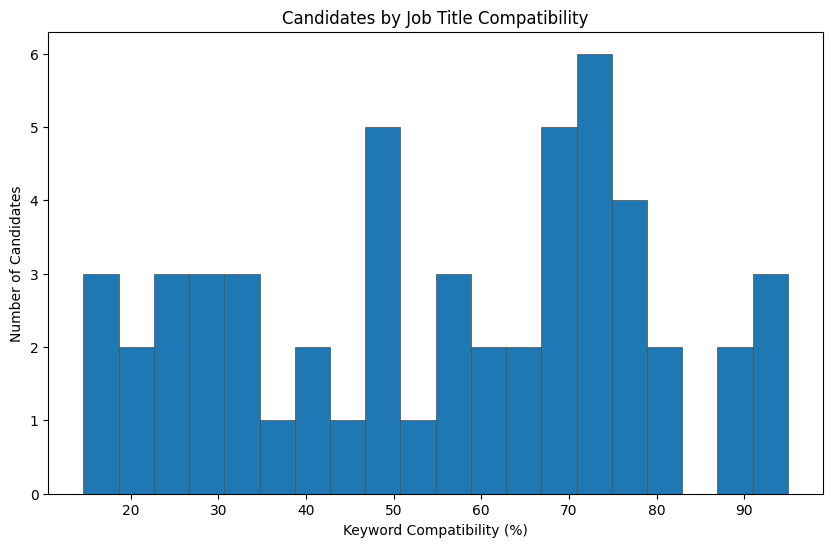

In [13]:
fig = plt.subplots(1, 1, figsize=(10,6))

# Ploting graph that shows the distribution of candiodate's job title compatibility in ralation with the Keywords
plt.hist(data['fit']*100, bins=20, linewidth=.5, edgecolor='.3')

plt.xlabel("Keyword Compatibility (%)")
plt.ylabel("Number of Candidates")
plt.title("Candidates by Job Title Compatibility")

This histogram shows the distribution of keyword compatibility scores across candidates.

**Scores near 0% indicate no meaningful overlap with the keywords, suggesting low relevance**. Higher scores indicate stronger alignment, with **values above 60% representing highly relevant candidates**.

### Filtering Top Candidates

In [14]:
# That's the quantity (in percentage) of candidates that will remain on the dataset in percentage
percentage = 50 # %

highest_scores_quantity = int(len(sorted_fit_data)*(percentage/100))

# Now the sorted dataset only has the (PERCENTAGE)% top fit values
sorted_fit_data = sorted_fit_data[: highest_scores_quantity]

# This will print the current lowest values candidates
sorted_fit_data.tail(5)

,job_title,location,connection,fit
24,Aspiring Human Resources Professional | Passio...,"New York, New York",212,0.677086
0,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,0.664928
26,Human Resources Generalist at Schwan's,Amerika Birleşik Devletleri,500+,0.653600
11,Human Resources Coordinator at InterContinenta...,"Atlanta, Georgia",500+,0.601090
18,"Retired Army National Guard Recruiter, office ...","Virginia Beach, Virginia",82,0.599741


Only the top `percentage` (**50%** in this case) of candidates are retained for further analysis.

This step **removes low-relevance candidates**, ensuring that subsequent ranking focuses only on the most relevant profiles.

## Features Engineering

In [15]:
# Selecting features that will be used on future comparisons
selected_features = sorted_fit_data[['location','connection','fit']].copy()

# Transforming "connection" to integer format
selected_features['connection'] = selected_features['connection'].map(lambda x: 500 if x == "500+ " else pd.to_numeric(x))

The `connection` feature is originally stored as a string, which prevents numerical operations. This step converts it into an integer format, making it suitable for mathematical processing.

### Transforming Categorical Feature

In [16]:
# Preparing encoder
ohe = OneHotEncoder(sparse_output=False).set_output(transform='pandas')

# Encoding "location" using "one hot encoding"
ohe_transformation = ohe.fit_transform(selected_features[['location']])

# Adding the new encoding columns to the dataframe and removing the old "location" column
selected_features = pd.concat([selected_features, ohe_transformation], axis=1).drop(columns='location')

The categorical feature `location` is transformed using One Hot Encoding, converting it into multiple binary columns that can be used in similarity calculations.

### Normalization

In [17]:
# Normalizing the "connection" and "fit" columns (the numeric features)
preprocessor = make_column_transformer(
    (MinMaxScaler(), ['connection', 'fit']),          
    remainder='passthrough'                              
)

# Fiting the normalized selected features in the X variable
X = preprocessor.fit_transform(selected_features)

Normalization **scales numerical features (`connection` and `fit`) to a common range**.

This is **essential for similarity calculations**, as it prevents features with larger values from dominating the results.

## Selecting "Role" Candidate

In [18]:
# Selecting candidate, in this case the 7th candidate
candidate = 7

# The index starts at 0, so we just adjust the index value to be in the correct order
role_idx = candidate - 1 

# Reshaping vector for vector operation (it is now a 1 x features vector
role_vector = X[role_idx].reshape(1, -1)

# Printing the vector for the "role" candidate
selected_features.iloc[role_idx]

connection                                      16.000000
fit                                              0.794648
location_Amerika Birleşik Devletleri             0.000000
location_Atlanta, Georgia                        0.000000
location_Austin, Texas Area                      0.000000
location_Baton Rouge, Louisiana Area             0.000000
location_Cape Girardeau, Missouri                0.000000
location_Chicago, Illinois                       0.000000
location_Greater Boston Area                     1.000000
location_Greater New York City Area              0.000000
location_Greater Philadelphia Area               0.000000
location_Houston, Texas                          0.000000
location_Houston, Texas Area                     0.000000
location_Jackson, Mississippi Area               0.000000
location_Kanada                                  0.000000
location_Kokomo, Indiana Area                    0.000000
location_Las Vegas, Nevada Area                  0.000000
location_Milpi

A candidate is **selected as a reference ("role" candidate) to guide the second ranking stage.**

This manual selection may introduce bias. One alternative is to define desired attributes beforehand (e.g., preferred locations or minimum connections), allowing the process to be more objective and automated.

## Sorting Dataframe by "Role" Candidate Similarity

In [19]:
# Get the similarity between ALL candidates in the dataframe and the "role" candidate
selected_features['fit'] = cosine_similarity(X, role_vector).flatten()

# Sort the candidates by "fit" (similarity with "role" candidate)
selected_features = selected_features.sort_values('fit', ascending=False)

# Print the first 10 candidates
selected_features.head(10)

,connection,fit,location_Amerika Birleşik Devletleri,"location_Atlanta, Georgia","location_Austin, Texas Area","location_Baton Rouge, Louisiana Area","location_Cape Girardeau, Missouri","location_Chicago, Illinois",location_Greater Boston Area,location_Greater New York City Area,...,"location_Houston, Texas Area","location_Jackson, Mississippi Area",location_Kanada,"location_Kokomo, Indiana Area","location_Las Vegas, Nevada Area","location_Milpitas, California","location_Monroe, Louisiana Area","location_New York, New York","location_Raleigh-Durham, North Carolina Area","location_Virginia Beach, Virginia"
22,16,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,44,0.344816,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
45,71,0.344768,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1,0.332648,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,48,0.320136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
13,390,0.285333,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30,174,0.217307,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,500,0.205663,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,61,0.201792,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48,103,0.195580,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
# Print the last 10 candidates
selected_features.tail(10)

,connection,fit,location_Amerika Birleşik Devletleri,"location_Atlanta, Georgia","location_Austin, Texas Area","location_Baton Rouge, Louisiana Area","location_Cape Girardeau, Missouri","location_Chicago, Illinois",location_Greater Boston Area,location_Greater New York City Area,...,"location_Houston, Texas Area","location_Jackson, Mississippi Area",location_Kanada,"location_Kokomo, Indiana Area","location_Las Vegas, Nevada Area","location_Milpitas, California","location_Monroe, Louisiana Area","location_New York, New York","location_Raleigh-Durham, North Carolina Area","location_Virginia Beach, Virginia"
12,500,0.132915,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14,57,0.131087,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27,7,0.121670,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24,212,0.106990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
19,500,0.105342,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
42,415,0.100111,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,85,0.092114,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,500,0.071049,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,500,0.019890,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18,82,0.004207,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### "Role" Candidate Compatibility Performance 

Text(0.5, 1.0, "Candidates by 'Role' Candidate Compatibility")

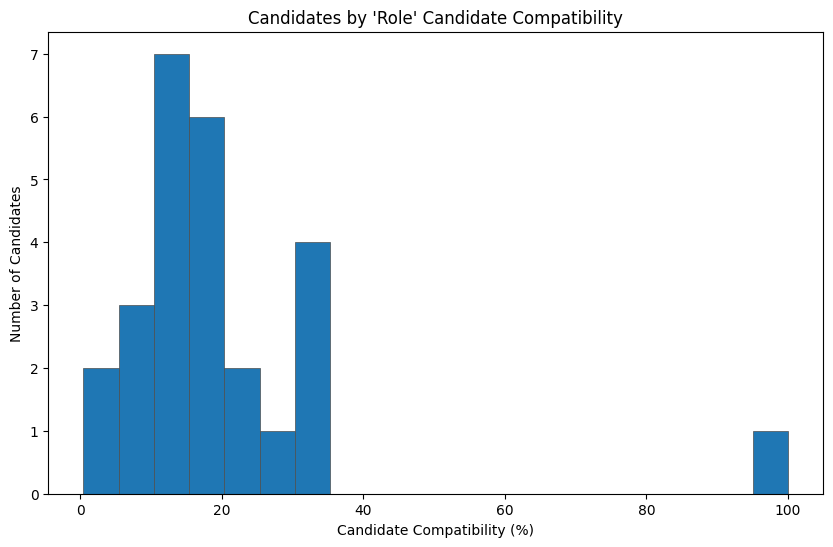

In [21]:
fig = plt.subplots(1, 1, figsize=(10,6))

# Ploting graph that shows the distribution of candiodate's job title compatibility in ralation with the Keywords
plt.hist(selected_features['fit']*100, bins=20, linewidth=.5, edgecolor='.3')

plt.xlabel("Candidate Compatibility (%)")
plt.ylabel("Number of Candidates")
plt.title("Candidates by 'Role' Candidate Compatibility")

This histogram shows the **compatibility of candidates relative to the selected "role" candidate.**

**Higher percentages indicate greater similarity**. Since the dataset was pre-filtered, the number of candidates is lower than the previous graph.